# MSC Geomet - Using Authentication to Access Flow Predictions 
# Using the Web Map Service

This notebook provides examples of how to use user/password authentication on Meteorological Service of Canada's (MSC) [GeoMet](https://eccc-msc.github.io/open-data/msc-geomet/readme_en/#msc-geomet "MSC GeoMet Open Documentation") platform, in order to access flow prediction through the web map service (WMS) with Python. If you are interested in retrieving flow predictions with the web coverage service (WCS), please see the companion tutorial in this repository. If you are unsure of which service to use, a general rule of thumb is that the web map service is primarily used to retrieve geospatial images and the web coverage service is used to retrieve raw geospatial data. If you are new to the WMS and the WCS we recommend later visiting the [documentation](https://eccc-msc.github.io/open-data/msc-geomet/readme_en/#usage-tutorials-and-technical-documentation "MSC GeoMet Usage, Tutorials, and Technical Documentation") on the MSC Open Data website. If you would like additional details, you can also view the [technical documentation](https://eccc-msc.github.io/open-data/msc-geomet/wms_en/ "MSC GeoMet Technical Documentation").

## Table of Contents

* [Requirements](#Requirements)
* [Introduction to Web Map Service](#Introduction-to-Web-Map-Service)
* [Non-authenticated vs authenticated data](#Non-athenticated-vs-authenticated-data)
* [Accessing layer information](#Accessing-layer-information)
* [Viewing with WMS](#Viewing-with-WMS)
* [Viewing with Matplotlib/Cartopy](#Viewing-with-Matplotlib-/-Cartopy)

## Requirements

First, we import all necessary Python libraries.  Some of these are standard Python libraries, while others are third-party libraries that must first be installed in your Python environment. The most important of these third-party libraries is [OWSLib](https://geopython.github.io/OWSLib/index.html "OWSLib Documentation"), which stands for the Open Geospatial Consortium (OGC) web service and which we'll use for accessing the Geomet WMS and WCS. We also recommend [xarray](https://docs.xarray.dev/en/stable/ "xarray Documentation"), for data handling and [cartopy](https://scitools.org.uk/cartopy/docs/latest/) for viewing the data.

In [1]:
# data
import warnings
import re
import time
import configparser
from datetime import datetime, timedelta
import xarray as xr 

# web map services 
from owslib.wms import WebMapService
from owslib.wcs import WebCoverageService
from owslib.wcs import Authentication

# plotting
from IPython.display import Image
import cartopy.crs as ccrs
import cartopy.feature as cf
# matplotlib is a third-party library, but is commonly included in Python distributions for data science
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
from matplotlib import cm

To access the flow prediction from the user/password authenticated version of GeoMet, we need credentials. We can use the built-in configparser utility library, which reads a file with the following format:

```
[Login]
Username = your_user_name 
Password = your_password
```

In [2]:
config = configparser.ConfigParser()
config.read_file(open('config.cfg'))

login = config['Login']

## Introduction to Web Map Service

The Geomet WMS provides access to georeferenced map images, also known as raster images or tiles. These display hydro-meteorological variables from multiple MSC monitoring and numerical modelling systems and their related products.  Included with the map images is descriptive information, i.e., metadata, that includes attributes describing each of the different map images and how they should be displayed.  Together, the descriptive information and images are called layers. 

We can connect to the WMS using OWSlib.  The typical way to do this without authentication is as follows:

In [3]:
# filter warnings or be prepared to see plenty
warnings.filterwarnings('ignore', module='owslib', category=UserWarning)

# connect to web map service
wms = WebMapService(f'https://geo.weather.gc.ca/geomet?&SERVICE=WMS',
                    version='1.3.0',
                    timeout=300)

In [4]:
# print the "abstract" for the GeoMet WMS
print(wms.identification.abstract)

GeoMet-Weather provides public access to the Meteorological Service of Canada (MSC) and Environment and Climate Change Canada (ECCC) data via interoperable web services and application programming interfaces (API). Through open standards, users can freely and quickly access thousands of real-time and archived weather, climate and water datasets and products and integrate them in their domain-specific applications and decision support systems. Users can build mobile apps, create interactive web maps, and display and animate MSC data in desktop software. MSC GeoMet also enables on demand raw data clipping and reprojection, on demand format conversion and custom visualization.


In [5]:
# some additional wms metadata
print("URL: " + wms.url)
print("Version: " + wms.version)
print("Provider: " + wms.provider.name)
print("Provider URL: " + wms.provider.url)

URL: https://geo.weather.gc.ca/geomet
Version: 1.3.0
Provider: Government of Canada, Environment and Climate Change Canada, Meteorological Service of Canada
Provider URL: https://eccc-msc.github.io/open-data/msc-geomet/readme_en/


In [6]:
# let's print the operations available from the wms and the product formatting options
for op in wms.operations:
    print(op.name, op.formatOptions)

GetCapabilities ['text/xml']
GetMap ['image/png', 'image/jpeg']
GetFeatureInfo ['text/plain', 'application/json', 'application/vnd.ogc.gml']
DescribeLayer ['text/xml']
GetLegendGraphic ['image/png', 'image/jpeg', 'image/png; mode=8bit', 'image/vnd.jpeg-png', 'image/vnd.jpeg-png8']
GetStyles ['text/xml']


In [7]:
# by default, when we connected to the web map service above, we were making a GetCapabilities request
print(wms.request)

https://geo.weather.gc.ca/geomet?service=WMS&request=GetCapabilities&version=1.3.0


## Non-athenticated vs authenticated data

Once we have established a connection to the web map service, we can view the available layers.

In [8]:
# let's have a look at the first 20 data layers in the wms contents
print(len(wms.contents))
for key in list(wms.contents.keys())[0:20]:
    print(key)

7833
Canadian Weather
ALERTS
CURRENT_CONDITIONS
Lightning_2.5km_Density
METNOTES
Marine-Standard-Forecast-Zones
Public-Standard-Forecast-Zones
Surface Weather Observations (SWOB) Stations
SWOB-Marine-Stations
SWOB-Partner-Stations
SWOB-Surface-Stations
Air Quality
Air Quality Health Index (AQHI)
AQHI-OBS
Regional Air Quality Deterministic Prediction System - FireWork (RAQDPS-FW) [10 km]
RAQDPS-FW.CE_Footprint
Cumulative Effects
Hotspots
RAQDPS-FW.CE_HOTSPOTS.2013
RAQDPS-FW.CE_HOTSPOTS.2014


In [9]:
# let's check what data are available for the Water Cycle Prediction System (WCPS)
for key in list(wms.contents.keys()):
    if "WCPS" in key:
        print(key)

Water Cycle Prediction System (WCPS) [1 km]
WCPS-Ocean-Atm_Footprint
WCPS-Rivers_Footprint
WCPS-Ocean-Atmosphere
WCPS_1km_AirTemp_1.5m
WCPS_1km_MixedLayerThickness
WCPS_1km_Runoff
WCPS_1km_SeaIceAreaFraction
WCPS_1km_SeaIceCompressiveStrength
WCPS_1km_SeaIceDivergence
WCPS_1km_SeaIceInternalPressure
WCPS_1km_SeaIceShear
WCPS_1km_SeaIceSnowTemp
WCPS_1km_SeaIceSnowVol
WCPS_1km_SeaIceVelocity
WCPS_1km_SeaIceVol
WCPS_1km_SeaSfcHeight
WCPS_1km_SeaWaterPotentialTemp_0.5m
WCPS_1km_SeaWaterSalinity_0.5m
WCPS_1km_SeaWaterVelocity_0.5m
WCPS_1km_TurboclineDepth
WCPS_1km_WindsU_10m
WCPS_1km_WindsV_10m
WCPS_1km_Winds_10m


This list tells us what the layer names are for the available WCPS data, but they aren't very descriptive. Let's print their titles instead.

In [11]:
# let's have a look at the variable names
for key in list(wms.contents.keys()):
    if "WCPS" in key:
        print(wms[key].title)

Water Cycle Prediction System (WCPS) [1 km]
WCPS-Ocean-Atmosphere footprint
WCPS-Rivers footprint
WCPS-Ocean-Atmosphere
WCPS - Surface air temperature at 1.5 m above ground [K]
WCPS - Ocean mixed layer depth based on density criterion [m]
WCPS - Runoff [mm]
WCPS - Sea ice area fraction
WCPS - Depth-integrated compressive sea ice strength [N/m]
WCPS - Sea ice divergence [%/day]
WCPS - Depth-integrated internal sea ice pressure [N/m]
WCPS - Sea ice shear [%/day]
WCPS - Surface temperature of snow over sea ice or bare sea ice [K]
WCPS - Volume of snow on sea ice per unit grid cell area [m]
WCPS - Sea ice velocity [m/s]
WCPS - Sea ice volume per unit grid cell area [m]
WCPS - Sea surface height above geoid [m]
WCPS - Sea water potential temperature at 0.5 m below the surface [K]
WCPS - Sea water salinity at 0.5 m below the surface [psu]
WCPS - Sea water velocity at 0.5 m below the surface [m/s]
WCPS - Turbocline depth [m]
WCPS - Surface wind U vector at 10 m above ground [m/s]
WCPS - Surfa

Now we have a better idea of what layers are available. Note that we don't have river discharge listed here. Let's check what we have available for the Deterministic Hydrologic Prediction Systems (DHPS).

In [12]:
# look for DHPS or EHPS, nothing returned
for key in list(wms.contents.keys()):
    if "DHPS" in key:
        print(key)

Deterministic Hydrological Prediction System (DHPS) [1 km]
DHPS_Footprint


The reason we don't see any data for DHPS is that the layers are not just password-protected, they are completely hidden. We must know the name of the hidden layer we are interested ahead of time. 

To connect to the authenticated version of WMS, we do one of the following:

In [13]:
# pass the layer name to the request
layer_name = 'DHPS_1km_RiverDischarge'

# use username and password parameters individually
wms = WebMapService(f'https://geo.weather.gc.ca/geomet?&SERVICE=WMS&LAYERS={layer_name}',
                    version='1.3.0',
                    username=login['Username'],
                    password=login['Password'],
                    timeout=300)

for key in list(wms.contents.keys()):
    print(key)

Deterministic Hydrological Prediction System (DHPS) [1 km]
DHPS
DHPS_1km_RiverDischarge


In [14]:
# use auth parameter with Authentication utility
wms = WebMapService(f'https://geo.weather.gc.ca/geomet?&SERVICE=WMS&LAYERS={layer_name}',
                    version='1.3.0',
                    auth=Authentication(username=login['Username'], password=login['Password']),
                    timeout=300)

for key in list(wms.contents.keys()):
    print(key)

Deterministic Hydrological Prediction System (DHPS) [1 km]
DHPS
DHPS_1km_RiverDischarge


The second approach with `auth = Authentication(username, password)` is preferable since it is the only method that works with the Web Coverage Service.

Note again that layers are hidden unless the layer name is defined.  You can see this by connecting to the WMS and providing authentication, but no layer information is available:

In [15]:
# use auth parameter with Authentication utility
wms = WebMapService(f'https://geo.weather.gc.ca/geomet?&SERVICE',
                    version='1.3.0',
                    auth=Authentication(username=login['Username'], password=login['Password']),
                    timeout=300)

# looking for WCPS, DHPS or EHPS, still no flow predictions are returned
for key in list(wms.contents.keys()):
    if "WCPS" in key or "DHPS" in key:
        print(key)

Deterministic Hydrological Prediction System (DHPS) [1 km]
DHPS_Footprint
Water Cycle Prediction System (WCPS) [1 km]
WCPS-Ocean-Atm_Footprint
WCPS-Rivers_Footprint
WCPS-Ocean-Atmosphere
WCPS_1km_AirTemp_1.5m
WCPS_1km_MixedLayerThickness
WCPS_1km_Runoff
WCPS_1km_SeaIceAreaFraction
WCPS_1km_SeaIceCompressiveStrength
WCPS_1km_SeaIceDivergence
WCPS_1km_SeaIceInternalPressure
WCPS_1km_SeaIceShear
WCPS_1km_SeaIceSnowTemp
WCPS_1km_SeaIceSnowVol
WCPS_1km_SeaIceVelocity
WCPS_1km_SeaIceVol
WCPS_1km_SeaSfcHeight
WCPS_1km_SeaWaterPotentialTemp_0.5m
WCPS_1km_SeaWaterSalinity_0.5m
WCPS_1km_SeaWaterVelocity_0.5m
WCPS_1km_TurboclineDepth
WCPS_1km_WindsU_10m
WCPS_1km_WindsV_10m
WCPS_1km_Winds_10m


<div class="alert alert-block alert-warning">
<b>So to use the authenticated version of Geomet, whether WMS or WCS, you have to provide the layer name as well as the authentication information, which means you need to know the layer name you're looking for in advance of the request.
</div>

Luckily, here's a list of layers:

In [16]:
# DHPS_1km_CorrectedFlowDir
# DHPS_1km_DeepReservoirStorage_PT24H
# DHPS_1km_DrainageArea
# DHPS_1km_Evap-SpatialAvg12h_PT12H
# DHPS_1km_Precip-SpatialAvg12h_PT12H
# DHPS_1km_RiverChannelStorage_PT24H
# DHPS_1km_RiverDischarge
# DHPS_1km_TotalRunoff-Avg12h_PT12H
# DHPS_1km_WaterbodyID
# DHPS-Analysis_1km_RiverDischarge
# DHPS-Analysis_1km_DeepReservoirStorage
# DHPS-Analysis_1km_Evap-SpatialAvg12h
# DHPS-Analysis_1km_Precip-SpatialAvg12h
# DHPS-Analysis_1km_RiverChannelStorage
# DHPS-Analysis_1km_TotalRunoff-Avg12h

# WCPS-Rivers_1km_CorrectedFlowDir
# WCPS-Rivers_1km_DeepReservoirStorage_PT24H
# WCPS-Rivers_1km_DrainageArea
# WCPS-Rivers_1km_Evap-SpatialAvg12h_PT12H
# WCPS-Rivers_1km_Precip-SpatialAvg12h_PT12H
# WCPS-Rivers_1km_RiverChannelStorage_PT24H
# WCPS-Rivers_1km_RiverDischarge
# WCPS-Rivers_1km_TotalRunoff-Avg12h_PT12H
# WCPS-Rivers_1km_WaterbodyID
# WCPS-Rivers-Analysis_1km_RiverDischarge
# WCPS-Rivers-Analysis_1km_DeepReservoirStorage
# WCPS-Rivers-Analysis_1km_Evap-SpatialAvg12h
# WCPS-Rivers-Analysis_1km_Precip-SpatialAvg12h
# WCPS-Rivers-Analysis_1km_RiverChannelStorage

## Accessing layer information

To know what metadata information comes packaged with a layer, we can look at the layer details.

In [17]:
layer_name = 'DHPS_1km_RiverDischarge'

wms = WebMapService(f'https://geo.weather.gc.ca/geomet?&SERVICE=WMS&LAYERS={layer_name}',
                    version='1.3.0',
                    auth=Authentication(username=login['Username'], password=login['Password']),
                    timeout=300)

# layer details
for key, value in vars(wms[layer_name]).items():
    if value: # not all layers have values for the full set of available details
        print(key) # let's just print the details applicable to this layer

auth
parent
index
id
name
queryable
title
abstract
boundingBoxWGS84
boundingBox
crsOptions
styles
keywords
timepositions
defaulttimeposition
dimensions
metadataUrls


In [18]:
# let's have a look at some of the details
print(wms[layer_name].title)
print(wms[layer_name].boundingBoxWGS84)

DHPS - Streamflow discharge [m³/s]
(-168.433366, 38.991633, -52.500045, 71.599969)


Now let's look at the time metadata. For forecasts, there are two types of time metadata, "reference_time" and "time". The reference times refer to the available forecast issue times (model run times). "time" gives information about the timesteps of a specific forecast/analysis issue.

Differently, for analyses, 'reference_time' is no longer included in the metadata. Now, the "time" metadata gives information on the oldest available analysis time, the most recent available analysis time, and the analysis timestep.

In [24]:
# time metadata is stored in the dimensions attribute
wms[layer_name].dimensions['reference_time']['values']

['2025-07-21T00:00:00Z/2025-07-23T00:00:00Z/PT12H']

This is a bit hard to read, let's split the strings and print the time reference time information.

In [20]:
# formatting the reference time information
first, last, interval = wms[layer_name].dimensions['reference_time']['values'][0].split('/')
print('The first forecast issue is available at: ' + first)
print('The last forecast issue is available at: ' + last)
print('The hourly interval between issued forecasts is: ' + interval)

The first forecast issue is available at: 2025-07-21T00:00:00Z
The last forecast issue is available at: 2025-07-23T00:00:00Z
The hourly interval between issued forecasts is: PT12H


Now we know what forecast issues are available, but we haven't specified a forecast issue or model run in any of our earlier requests. What model run do we receive as a default?

In [21]:
# looking at the default reference time
wms[layer_name].dimensions['reference_time']['default']

'2025-07-23T00:00:00Z'

We can look at the same information for "time".

In [22]:
# formatting the time information
first, last, interval = wms[layer_name].dimensions['time']['values'][0].split('/')
print('The first datetime available is: ' + first)
print('The last datetime available is: ' + last)
print('The hourly interval between available times is: ' + interval)

The first datetime available is: 2025-07-23T01:00:00Z
The last datetime available is: 2025-07-29T00:00:00Z
The hourly interval between available times is: PT1H


The first and last available datetimes above correspond to the first and last available datetimes for the default reference time. There is a default time value as well:

In [23]:
# looking at the default time
wms[layer_name].dimensions['time']['default']

'2025-07-23T14:00:00Z'

## Viewing with WMS

In [25]:
wms = WebMapService(f'https://geo.weather.gc.ca/geomet?&SERVICE=WMS&LAYERS={layer_name}',
                    version='1.3.0',
                    auth=Authentication(username=login['Username'], password=login['Password']),
                    timeout=300)

The DHPS flow prediction layers have been given multiple styles in order to deal with the wide range in magnitude of flows across Canada

In [26]:
wms[layer_name].styles

{'RiverDischarge': {'title': 'RiverDischarge',
  'legend': 'https://geo.weather.gc.ca/geomet?version=1.3.0&service=WMS&request=GetLegendGraphic&sld_version=1.1.0&layer=DHPS_1km_RiverDischarge&format=image/png&STYLE=RiverDischarge',
  'legend_width': '150',
  'legend_height': '125',
  'legend_format': 'image/png'},
 'RiverDischarge_S': {'title': 'RiverDischarge_S',
  'legend': 'https://geo.weather.gc.ca/geomet?version=1.3.0&service=WMS&request=GetLegendGraphic&sld_version=1.1.0&layer=DHPS_1km_RiverDischarge&format=image/png&STYLE=RiverDischarge_S',
  'legend_width': '150',
  'legend_height': '125',
  'legend_format': 'image/png'},
 'RiverDischarge_M': {'title': 'RiverDischarge_M',
  'legend': 'https://geo.weather.gc.ca/geomet?version=1.3.0&service=WMS&request=GetLegendGraphic&sld_version=1.1.0&layer=DHPS_1km_RiverDischarge&format=image/png&STYLE=RiverDischarge_M',
  'legend_width': '150',
  'legend_height': '125',
  'legend_format': 'image/png'},
 'RiverDischarge_L': {'title': 'RiverDis

Let's check them out!

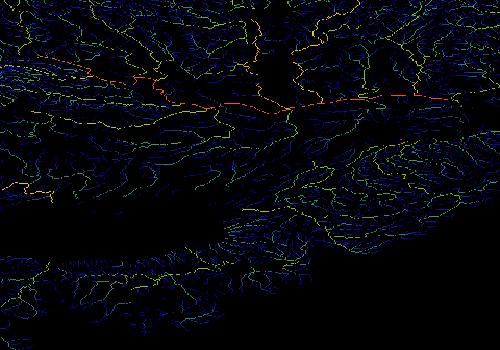

In [27]:
width = 500
height = 350

# example of how to get a map with specific extent covering eastern Ontario / southern Quebec
response = wms.getmap(layers=[layer_name],
                      format='image/jpeg',
                      srs='EPSG:4326',
                      bbox=(-78, 42, -74, 47),
                      size=(width, height),
                      transparent=True)

# show image
Image(response.read(), width=width, height=height)  # exciting!

In [28]:
response.geturl()

'https://geo.weather.gc.ca/geomet?service=WMS&version=1.3.0&request=GetMap&layers=DHPS_1km_RiverDischarge&styles=&width=500&height=350&crs=EPSG:4326&bbox=42,-78,47,-74&format=image/jpeg&transparent=TRUE&bgcolor=0xFFFFFF&exceptions=XML'

First tip, you need to indicate the style you want in the getmap request.  

Let's see what it would look like with "RiverDischarge_XL" styling:

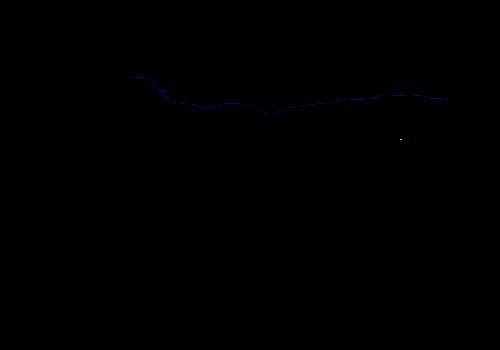

In [35]:
width = 500
height = 350

# example of how to get a map with specific extent covering eastern Ontario / southern Quebec
response = wms.getmap(layers=[layer_name],
                      format='image/jpeg',
                      srs='EPSG:4326',
                      styles=['RiverDischarge_XL'], # this only shows large rivers
                      bbox=(-78, 42, -74, 47),
                      size=(width, height),
                      transparent=True)

# show image
Image(response.read(), width=width, height=height)  # still not exciting!

Let's try the "RiverDischarge" style instead.

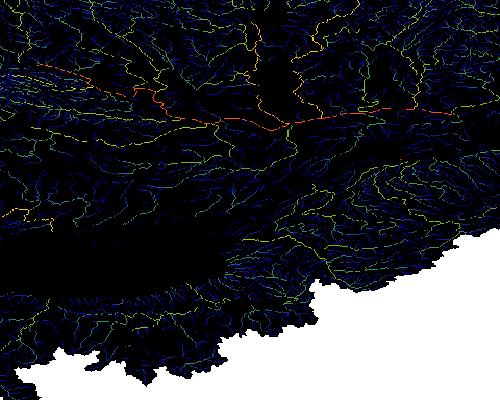

In [36]:
width = 500
height = 400

# example of how to get a map with specific extent covering eastern Ontario / southern Quebec
response = wms.getmap(layers=[layer_name],
                      format='image/png',
                      srs='EPSG:4326',
                      styles=['RiverDischarge'],  
                      bbox=(-78, 42, -74, 47),
                      size=(width, height),
                      transparent=True)

# show image
Image(response.read(), width=width, height=height)  

## Viewing with Matplotlib / Cartopy

Text(0.5, 1.0, 'WMS example - Layer : DHPS_1km_RiverDischarge')

c:\Users\bayerc\AppData\Local\anaconda3\envs\geomet\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\bayerc\AppData\Local\anaconda3\envs\geomet\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\bayerc\AppData\Local\anaconda3\envs\geomet\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\bayerc\AppData\Local\anaconda3\envs\geomet\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries_lakes.zip
  warnings.warn(f'Downloadi

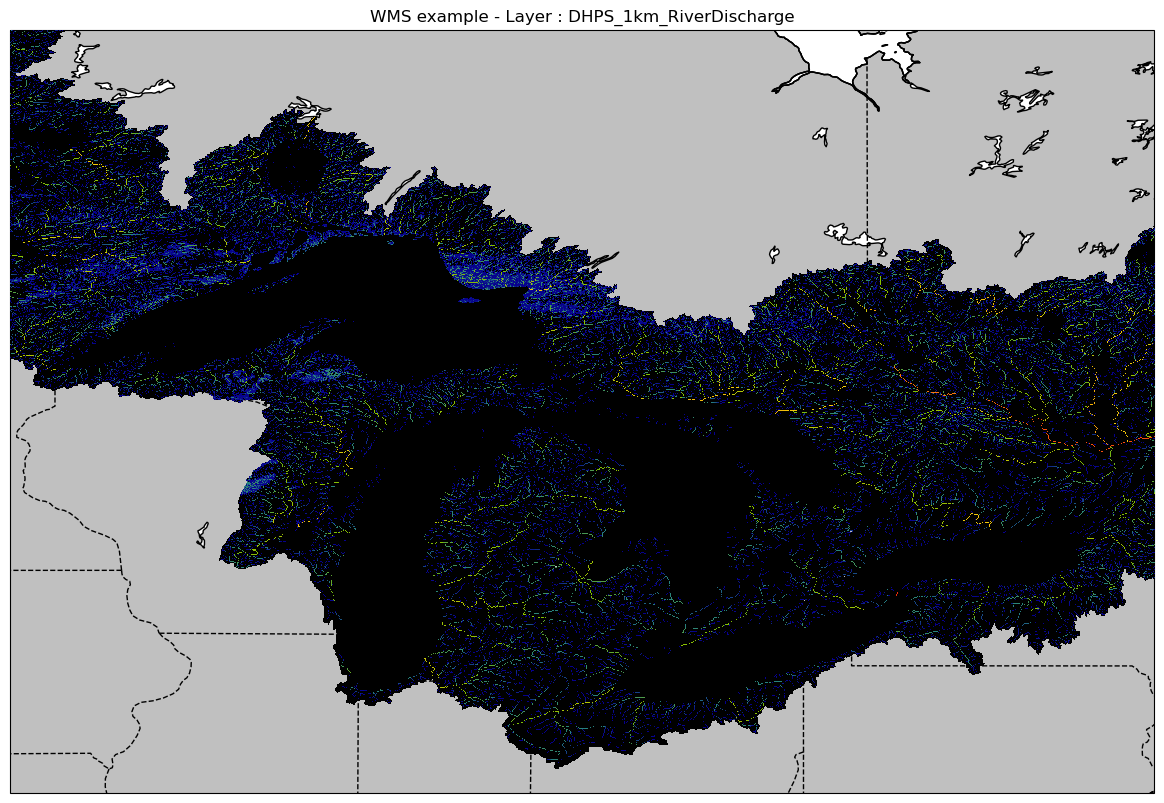

In [37]:
layer_name = 'DHPS_1km_RiverDischarge'
wms = WebMapService(f'https://geo.weather.gc.ca/geomet?&SERVICE=WMS&LAYERS={layer_name}',
                    version='1.3.0',
                    auth=Authentication(username=login['Username'], password=login['Password']),
                    timeout=300)

fig = plt.figure(figsize=(12,10))
projection = ccrs.PlateCarree()
ax = plt.axes(projection=projection)

ax.set_extent([-93, -75, 40, 52])

fig.tight_layout(pad=2)

# features
edgecolor = 'black'

# Cartopy features 
ax.add_feature(cf.LAND, facecolor='silver', edgecolor=edgecolor)
ax.add_feature(cf.COASTLINE, edgecolor=edgecolor)
ax.add_feature(cf.LAKES, facecolor="white", edgecolor=edgecolor)

# Natural Earth Features
countries = cf.NaturalEarthFeature(
        category='cultural',
        name='admin_0_countries_lakes',
        scale='10m',
        edgecolor=edgecolor,
        facecolor='none')
borders = cf.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        edgecolor=edgecolor,
        facecolor='none')

ax.add_feature(countries)
ax.add_feature(borders, linestyle='dashed')

ax.add_wms(wms=wms, 
           layers=[layer_name], 
           wms_kwargs = {'transparent' : True, 'styles' : ['RiverDischarge']}, 
           zorder=10)

ax.set_title(f'WMS example - Layer : {layer_name}')